In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Deep Learning Projects/ANN-HousePricePrediction/House Price Prediction Dataset.csv')
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
df['Id']

,Id
0,1
1,2
2,3
3,4
4,5
...,...
1995,1996
1996,1997
1997,1998
1998,1999


In [5]:
df.shape

(2000, 10)

In [6]:
df['Age'] = 2026 - df['YearBuilt']
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,Age
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919,56
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998,68
2,3,3592,2,2,3,1938,Downtown,Good,No,266746,88
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020,124
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056,51
...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620,103
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929,7
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925,123
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119,90


In [8]:
df['Garage'].unique()

array(['No', 'Yes'], dtype=object)

In [9]:
df['Garage'] = df['Garage'].replace({'No': 0, 'Yes': 1})
df

/tmp/ipython-input-347/918906609.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Garage'] = df['Garage'].replace({'No': 0, 'Yes': 1})


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,Age
0,1,1360,5,4,3,1970,Downtown,Excellent,0,149919,56
1,2,4272,5,4,3,1958,Downtown,Excellent,0,424998,68
2,3,3592,2,2,3,1938,Downtown,Good,0,266746,88
3,4,966,4,2,2,1902,Suburban,Fair,1,244020,124
4,5,4926,1,4,2,1975,Downtown,Fair,1,636056,51
...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,0,295620,103
1996,1997,3046,5,2,1,2019,Suburban,Poor,1,580929,7
1997,1998,1062,5,1,2,1903,Rural,Poor,0,476925,123
1998,1999,4062,3,1,2,1936,Urban,Excellent,1,161119,90


In [10]:
df['Location'].unique()

array(['Downtown', 'Suburban', 'Urban', 'Rural'], dtype=object)

In [11]:
df['Location'] = df['Location'].replace({'Downtown':0, 'Suburban':1, 'Urban':2, 'Rural':3})
df

/tmp/ipython-input-347/594644381.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Location'] = df['Location'].replace({'Downtown':0, 'Suburban':1, 'Urban':2, 'Rural':3})


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,Age
0,1,1360,5,4,3,1970,0,Excellent,0,149919,56
1,2,4272,5,4,3,1958,0,Excellent,0,424998,68
2,3,3592,2,2,3,1938,0,Good,0,266746,88
3,4,966,4,2,2,1902,1,Fair,1,244020,124
4,5,4926,1,4,2,1975,0,Fair,1,636056,51
...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,1,Poor,0,295620,103
1996,1997,3046,5,2,1,2019,1,Poor,1,580929,7
1997,1998,1062,5,1,2,1903,3,Poor,0,476925,123
1998,1999,4062,3,1,2,1936,2,Excellent,1,161119,90


In [12]:
df['Condition'].unique()

array(['Excellent', 'Good', 'Fair', 'Poor'], dtype=object)

In [13]:
df['Condition'] = df['Condition'].replace({'Excellent':0, 'Good':1, 'Fair':2, 'Poor':3})
df

/tmp/ipython-input-347/2815028275.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Condition'] = df['Condition'].replace({'Excellent':0, 'Good':1, 'Fair':2, 'Poor':3})


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,Age
0,1,1360,5,4,3,1970,0,0,0,149919,56
1,2,4272,5,4,3,1958,0,0,0,424998,68
2,3,3592,2,2,3,1938,0,1,0,266746,88
3,4,966,4,2,2,1902,1,2,1,244020,124
4,5,4926,1,4,2,1975,0,2,1,636056,51
...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,1,3,0,295620,103
1996,1997,3046,5,2,1,2019,1,3,1,580929,7
1997,1998,1062,5,1,2,1903,3,3,0,476925,123
1998,1999,4062,3,1,2,1936,2,0,1,161119,90


In [14]:
df = df.drop(columns=['Id','YearBuilt'])
df

,Area,Bedrooms,Bathrooms,Floors,Location,Condition,Garage,Price,Age
0,1360,5,4,3,0,0,0,149919,56
1,4272,5,4,3,0,0,0,424998,68
2,3592,2,2,3,0,1,0,266746,88
3,966,4,2,2,1,2,1,244020,124
4,4926,1,4,2,0,2,1,636056,51
...,...,...,...,...,...,...,...,...,...
1995,4994,5,4,3,1,3,0,295620,103
1996,3046,5,2,1,1,3,1,580929,7
1997,1062,5,1,2,3,3,0,476925,123
1998,4062,3,1,2,2,0,1,161119,90


In [15]:
X = np.array(df.drop(columns=['Price']))
Y = np.array(df['Price'])

In [16]:
X.shape

(2000, 8)

In [17]:
Y.shape

(2000,)

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [19]:
X_train.shape

(1600, 8)

In [20]:
Y_train.shape

(1600,)

In [21]:
X_test.shape

(400, 8)

In [22]:
Y_test.shape

(400,)

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()
model.add(Dense(400,activation='relu',input_shape=(X_train.shape[1],)))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(400,activation='relu'))
model.add(Dense(1,activation='linear'))

model.compile(optimizer='adam',loss='mean_squared_error',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_58 (Dense)                │ (None, 400)            │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 1)              │           401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,891,201 (11.03 MB)

 Trainable params: 2,891,201 (11.03 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
early_stop = EarlyStopping(monitor='val_loss',verbose=1,patience=25)

In [49]:
model.fit(X_train,Y_train,epochs=200,validation_data=(X_test,Y_test),callbacks=[early_stop])

Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.0000e+00 - loss: 287968854016.0000 - val_accuracy: 0.0000e+00 - val_loss: 88726224896.0000
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.0000e+00 - loss: 87057801216.0000 - val_accuracy: 0.0000e+00 - val_loss: 83770523648.0000
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.0000e+00 - loss: 85188976640.0000 - val_accuracy: 0.0000e+00 - val_loss: 84172308480.0000
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.0000e+00 - loss: 86401105920.0000 - val_accuracy: 0.0000e+00 - val_loss: 92724125696.0000
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.0000e+00 - loss: 96838254592.0000 - val_accuracy: 0.0000e+00 - val_loss: 104147124224.0000
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.0000e+00 - loss: 96472637440.0000 - val_accuracy: 0.0000e+00 - val_loss: 83431727104.0000
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accurac

<Axes: >

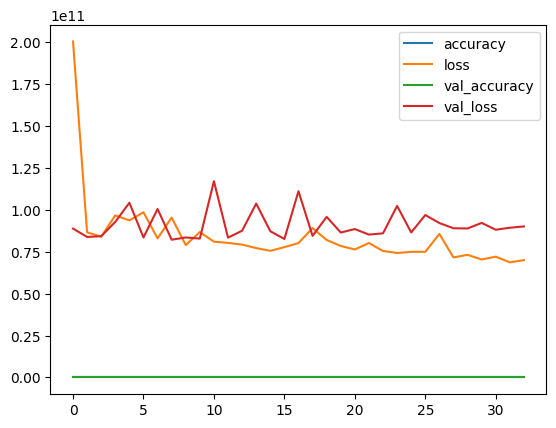

In [50]:
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [53]:
price = model.predict(X_test[10].reshape(1, -1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


In [54]:
price

array([[486073.56]], dtype=float32)

In [55]:
Y_test[10]

np.int64(913498)

In [56]:
model.evaluate(X_test,Y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0000e+00 - loss: 87243300864.0000


[90013614080.0, 0.0]